# ___Summaries of hOUwie model fits___
-------------------------------

In [2]:
print(R.version$version.string)

[1] "R version 4.5.2 (2025-10-31 ucrt)"


In [1]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("corHMM")
    library("OUwie")
    library("reshape2")
    library("ggplot2")
})

In [2]:
options(repr.plot.width = 30, repr.plot.height = 12)

In [30]:
files <- list.files("../rdata/parallel/LOG_SRL_1005SP/")
files

[1] "ARD_OUM_SRL_STATES_CD_.Rds"    "ARD_OUM_SRL_STATES_CID_.Rds"  
 [3] "ARD_OUMA_SRL_STATES_CD_.Rds"   "ARD_OUMA_SRL_STATES_CID_.Rds" 
 [5] "ARD_OUMV_SRL_STATES_CD_.Rds"   "ARD_OUMV_SRL_STATES_CID_.Rds" 
 [7] "ARD_OUMVA_SRL_STATES_CD_.Rds"  "ARD_OUMVA_SRL_STATES_CID_.Rds"
 [9] "ER_OUM_SRL_STATES_CD_.Rds"     "ER_OUM_SRL_STATES_CID_.Rds"   
[11] "ER_OUMA_SRL_STATES_CD_.Rds"    "ER_OUMA_SRL_STATES_CID_.Rds"  
[13] "ER_OUMV_SRL_STATES_CD_.Rds"    "ER_OUMV_SRL_STATES_CID_.Rds"  
[15] "ER_OUMVA_SRL_STATES_CD_.Rds"   "ER_OUMVA_SRL_STATES_CID_.Rds" 
[17] "SYM_OUM_SRL_STATES_CD_.Rds"    "SYM_OUM_SRL_STATES_CID_.Rds"  
[19] "SYM_OUMA_SRL_STATES_CD_.Rds"   "SYM_OUMA_SRL_STATES_CID_.Rds" 
[21] "SYM_OUMV_SRL_STATES_CD_.Rds"   "SYM_OUMV_SRL_STATES_CID_.Rds" 
[23] "SYM_OUMVA_SRL_STATES_CD_.Rds"  "SYM_OUMVA_SRL_STATES_CID_.Rds"

In [35]:
ifelse(test = TRUE, yes = files[grep(pattern = "CD", files)], no = files[grep(pattern = "CID", files)])

[1] "ARD_OUM_SRL_STATES_CD_.Rds"

In [15]:
gsub(list.files("../rdata/parallel/LOG_SRL_1005SP/"), pattern = "_SRL_STATES_C[I]*D_", replacement = "")

[1] "ARD_OUM.Rds"   "ARD_OUM.Rds"   "ARD_OUMA.Rds"  "ARD_OUMA.Rds" 
 [5] "ARD_OUMV.Rds"  "ARD_OUMV.Rds"  "ARD_OUMVA.Rds" "ARD_OUMVA.Rds"
 [9] "ER_OUM.Rds"    "ER_OUM.Rds"    "ER_OUMA.Rds"   "ER_OUMA.Rds"  
[13] "ER_OUMV.Rds"   "ER_OUMV.Rds"   "ER_OUMVA.Rds"  "ER_OUMVA.Rds" 
[17] "SYM_OUM.Rds"   "SYM_OUM.Rds"   "SYM_OUMA.Rds"  "SYM_OUMA.Rds" 
[21] "SYM_OUMV.Rds"  "SYM_OUMV.Rds"  "SYM_OUMVA.Rds" "SYM_OUMVA.Rds"

In [39]:
read_rds <- function(dirpath, cd, regstrip) {
    fnames <- list.files(dirpath) # all the files in the specified dir
    if(cd) fnames <- fnames[grep(pattern = "CD", fnames)]
    else fnames <- fnames[grep(pattern = "CID", fnames)] # cherry pick CD or CID models, assuming their names contain "CD" or "CID"
    # print(fnames)
    
    paths <- paste0(dirpath, fnames) # relative paths for all the Rds files
    stopifnot(length(fnames)==length(paths))
    
    mnames <- gsub(x = gsub(pattern = regstrip, replacement = '', x = fnames), pattern = '_', replacement = '') # remove the unnecessary parts of the file names to create the model names
    stopifnot(length(fnames)==length(mnames))

    models <- lapply(X = paths, FUN = readRDS) # read the needed Rds files into a list of objects
    stopifnot(length(models)==length(mnames))
    
    names(models) <- mnames # set their names
    models
}

## ___Root diameter (RD)___
-----------------------

In [ ]:
load("./rdata/OU_RD_CD.RData") # rate.cat=1, null.model=FALSE
load("./rdata/OU_RD_CID.RData") # rate.cat=2, null.model=TRUE

# find out the AIC and AICc of all the models

# rate.cat=1, null.model=FALSE
models_CD_RD <- list(EROUM=ER_OUM_RD_CD, EROUMA=ER_OUMA_RD_CD, EROUMV=ER_OUMV_RD_CD, EROUMVA=ER_OUMVA_RD_CD, ARDOUM=ARD_OUM_RD_CD, ARDOUMA=ARD_OUMA_RD_CD, ARDOUMV=ARD_OUMV_RD_CD, ARDOUMVA=ARD_OUMVA_RD_CD,
                     SYMOUM=SYM_OUM_RD_CD, SYMOUMA=SYM_OUMA_RD_CD, SYMOUMV=SYM_OUMV_RD_CD, SYMOUMVA=SYM_OUMVA_RD_CD)

# rate.cat=2, null.model=TRUE
models_CID_RD <- list(EROUM=ER_OUM_RD_CID, EROUMA=ER_OUMA_RD_CID, EROUMV=ER_OUMV_RD_CID, EROUMVA=ER_OUMVA_RD_CID, ARDOUM=ARD_OUM_RD_CID, ARDOUMA=ARD_OUMA_RD_CID, ARDOUMV=ARD_OUMV_RD_CID, ARDOUMVA=ARD_OUMVA_RD_CID,
                    SYMOUM=SYM_OUM_RD_CID, SYMOUMA=SYM_OUMA_RD_CID, SYMOUMV=SYM_OUMV_RD_CID, SYMOUMVA=SYM_OUMVA_RD_CID)


# model averages
# type - one of AIC, BIC, or AICc for use during evaluation of relative model fit.
# AICc (small sample size corrected AIC) is the best option for datasets with a few number of species.
# force - a boolean indicating whether to force potentially failed model fits to be included in the model averaging.

avg_models_CD_RD <- OUwie::getModelAvgParams(models_CD_RD, type = "AICc", force = FALSE)
avg_models_CID_RD <- OUwie::getModelAvgParams(models_CID_RD, type = "AICc", force = FALSE)

# look up to see what the BIC stuff is about
# https://www.rdocumentation.org/packages/AICcmodavg/versions/2.3-4/topics/bictabCustom
# AIC vs BIC
# https://fiveable.me/bayesian-statistics/unit-11/bayesian-information-criterion/study-guide/o3iS2biLgz7mcyuv

In [ ]:
plot_df <- reshape2::melt(avg_models_CID_RD)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")
# ggplot2::ggsave(plot = plot, filename = "../plots/hOUwie_RD_CID.png", device = "png", width = 22, height = 12, units = "in", dpi = 750)

In [ ]:
plot_df <- reshape2::melt(avg_models_CD_RD)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")
# ggplot2::ggsave(plot = plot, filename = "../plots/hOUwie_RD_CD.png", device = "png", width = 22, height = 12, units = "in", dpi = 750)

In [ ]:
avg_models_CD_RD[, c("alpha", "sigma.sq", "theta", "tip_state")] |> split(~tip_state)


# there's already a function named stderr in base R ???
stderr_ <- function(df) { lapply(X=df, FUN=function(column) {sd(column) / sqrt(length(column))}) |> unlist() }

avg_models_CD_RD |> split(~tip_state) |> lapply(function(df) { colMeans(df[, c("rates", "alpha", "sigma.sq", "theta")]) }) |> as.data.frame()
avg_models_CID_RD |> split(~tip_state) |> lapply(function(df) { colMeans(df[, c("rates", "alpha", "sigma.sq", "theta")]) }) |> as.data.frame()


avg_models_CD_RD |> split(~tip_state) |> lapply(function(df) { stderr_(df[, c("rates", "alpha", "sigma.sq", "theta")]) })

In [ ]:
load("./rdata/OU_RD_CID_4states.RData")
load("./rdata/OU_RD_CD_4states.RData")


models_CD_RD_4states <- list(EROUM=ER_OUM_RD_CD, EROUMA=ER_OUMA_RD_CD, EROUMV=ER_OUMV_RD_CD, EROUMVA=ER_OUMVA_RD_CD, ARDOUM=ARD_OUM_RD_CD,
                     ARDOUMA=ARD_OUMA_RD_CD, ARDOUMV=ARD_OUMV_RD_CD, ARDOUMVA=ARD_OUMVA_RD_CD, SYMOUM=SYM_OUM_RD_CD, SYMOUMA=SYM_OUMA_RD_CD,
                     SYMOUMV=SYM_OUMV_RD_CD, SYMOUMVA=SYM_OUMVA_RD_CD)

# rate.cat=2, null.model=TRUE
models_CID_RD_4states <- list(EROUM=ER_OUM_RD_CID, EROUMA=ER_OUMA_RD_CID, EROUMV=ER_OUMV_RD_CID, EROUMVA=ER_OUMVA_RD_CID,
                      ARDOUM=ARD_OUM_RD_CID, ARDOUMA=ARD_OUMA_RD_CID, ARDOUMV=ARD_OUMV_RD_CID, ARDOUMVA=ARD_OUMVA_RD_CID,
                      SYMOUM=SYM_OUM_RD_CID, SYMOUMA=SYM_OUMA_RD_CID, SYMOUMV=SYM_OUMV_RD_CID, SYMOUMVA=SYM_OUMVA_RD_CID)


lapply(models_CID_RD_4states, function(mod){c(mod$loglik, mod$AIC, mod$AICc)}) |> as.data.frame(row.names = c("lnLik", "AIC", "AICc"))
lapply(models_CD_RD_4states, function(mod){c(mod$loglik, mod$AIC, mod$AICc)}) |> as.data.frame(row.names = c("lnLik", "AIC", "AICc"))

avg_models_CD_RD_4states <- OUwie::getModelAvgParams(models_CD_RD_4states, type = "AICc", force = FALSE)
avg_models_CID_RD_4states <- OUwie::getModelAvgParams(models_CID_RD_4states, type = "AICc", force = FALSE)

plot_df <- reshape2::melt(avg_models_CID_RD_4states)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")
ggplot2::ggsave(plot = plot, filename = "../plots/hOUwie_RD_CID_4states.png", device = "png", width = 22, height = 12, units = "in", dpi = 750)


plot_df <- reshape2::melt(avg_models_CD_RD_4states)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")
ggplot2::ggsave(plot = plot, filename = "../plots/hOUwie_RD_CD_4states.png", device = "png", width = 22, height = 12, units = "in", dpi = 750)


stderr_ <- function(df) { lapply(X=df, FUN=function(column) {sd(column) / sqrt(length(column))}) |> unlist() }

avg_models_CD_RD_4states |> split(~tip_state) |> lapply(function(df) { colMeans(df[, c("rates", "alpha", "sigma.sq", "theta")]) }) |> as.data.frame()
avg_models_CID_RD_4states |> split(~tip_state) |> lapply(function(df) { colMeans(df[, c("rates", "alpha", "sigma.sq", "theta")]) }) |> as.data.frame()


avg_models_CD_RD_4states |> split(~tip_state) |> lapply(function(df) { stderr_(df[, c("rates", "alpha", "sigma.sq", "theta")]) })
avg_models_CID_RD_4states |> split(~tip_state) |> lapply(function(df) { stderr_(df[, c("rates", "alpha", "sigma.sq", "theta")]) })

In [8]:
#------------------------------------------------------------------------------------------------------------------------------------
# ROOT DIAMETER (RD <= 1.000 mm and root order == NA) or (RD <= 1.000 mm and root order == 1) subset (NOT LOG TRANSFORMED)
#------------------------------------------------------------------------------------------------------------------------------------

load("../rdata/OU_RD_CD_1005sp.RData")
load("../rdata/OU_RD_CID_1005sp.RData")

models_CD_RD_1005sp <- list(EROUM=ER_OUM_RD_CD, EROUMA=ER_OUMA_RD_CD, EROUMV=ER_OUMV_RD_CD, EROUMVA=ER_OUMVA_RD_CD, ARDOUM=ARD_OUM_RD_CD,
                              ARDOUMA=ARD_OUMA_RD_CD, ARDOUMV=ARD_OUMV_RD_CD, ARDOUMVA=ARD_OUMVA_RD_CD, SYMOUM=SYM_OUM_RD_CD, SYMOUMA=SYM_OUMA_RD_CD,
                              SYMOUMV=SYM_OUMV_RD_CD, SYMOUMVA=SYM_OUMVA_RD_CD)

models_CID_RD_1005sp <- list(EROUM=ER_OUM_RD_CID, EROUMA=ER_OUMA_RD_CID, EROUMV=ER_OUMV_RD_CID, EROUMVA=ER_OUMVA_RD_CID, ARDOUM=ARD_OUM_RD_CID,
                               ARDOUMA=ARD_OUMA_RD_CID, ARDOUMV=ARD_OUMV_RD_CID, ARDOUMVA=ARD_OUMVA_RD_CID, SYMOUM=SYM_OUM_RD_CID, SYMOUMA=SYM_OUMA_RD_CID,
                               SYM_OUMV=SYM_OUMV_RD_CID, SYMOUMVA=SYM_OUMVA_RD_CID)

# wrapping the expression inside invisible() did not work.
capture.output(avg_models_CD_RD_1005sp <- OUwie::getModelAvgParams(models_CD_RD_1005sp, type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_models_CID_RD_1005sp <- OUwie::getModelAvgParams(models_CID_RD_1005sp, type = "AICc", force = FALSE), file = nullfile())

OUwie::getModelTable(model.list = models_CD_RD_1005sp, type = "AICc")
OUwie::getModelTable(model.list = models_CID_RD_1005sp, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EROUM,10,115.95774,-262.3115,381.40216,-211.69415,0.00000,9.949291e-01
EROUMA,16,-187.02579,-262.3209,78.28670,406.60220,618.29635,5.450629e-135
EROUMV,16,116.84304,-262.2966,382.56272,-201.13548,10.55867,5.069979e-03
EROUMVA,22,-215.70147,-264.5613,42.09538,476.43350,688.12765,3.739147e-150
ARDOUM,51,31.45702,-238.3359,273.13968,44.65154,256.34569,2.152942e-56
ARDOUMA,57,-187.82765,-249.3991,61.98504,496.63735,708.33150,1.533067e-154
ARDOUMV,57,32.82636,-238.1989,266.00921,55.32932,267.02347,1.033672e-58
ARDOUMVA,63,-204.05384,-245.0047,39.58153,542.67728,754.37143,1.542119e-164
SYMOUM,30,122.88075,-240.2156,366.39338,-183.85185,27.84230,8.951864e-07


,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EROUM,8,105.57300,-262.3151,371.18507,-195.00142,0.000000,4.842426e-01
EROUMA,9,105.91936,-262.3385,371.57221,-193.65781,1.343609,2.473443e-01
EROUMV,9,105.97273,-262.3017,371.62537,-193.76455,1.236868,2.609038e-01
EROUMVA,10,103.44493,-262.4792,368.07729,-186.66853,8.332892,7.509283e-03
ARDOUM,90,-117.39833,-300.2429,165.24502,432.71788,627.719299,2.385333e-137
ARDOUMA,91,-120.01430,-299.2012,-31.47457,440.36815,635.369566,5.203730e-139
ARDOUMV,91,-99.68674,-288.4637,190.78015,399.71302,594.714442,3.503182e-130
ARDOUMVA,92,-264.30371,-287.7218,20.50068,731.37058,926.372003,3.356901e-202
SYMOUM,48,29.76371,-276.8561,309.32244,41.39308,236.394496,2.252425e-52


Using tip_state as id variables



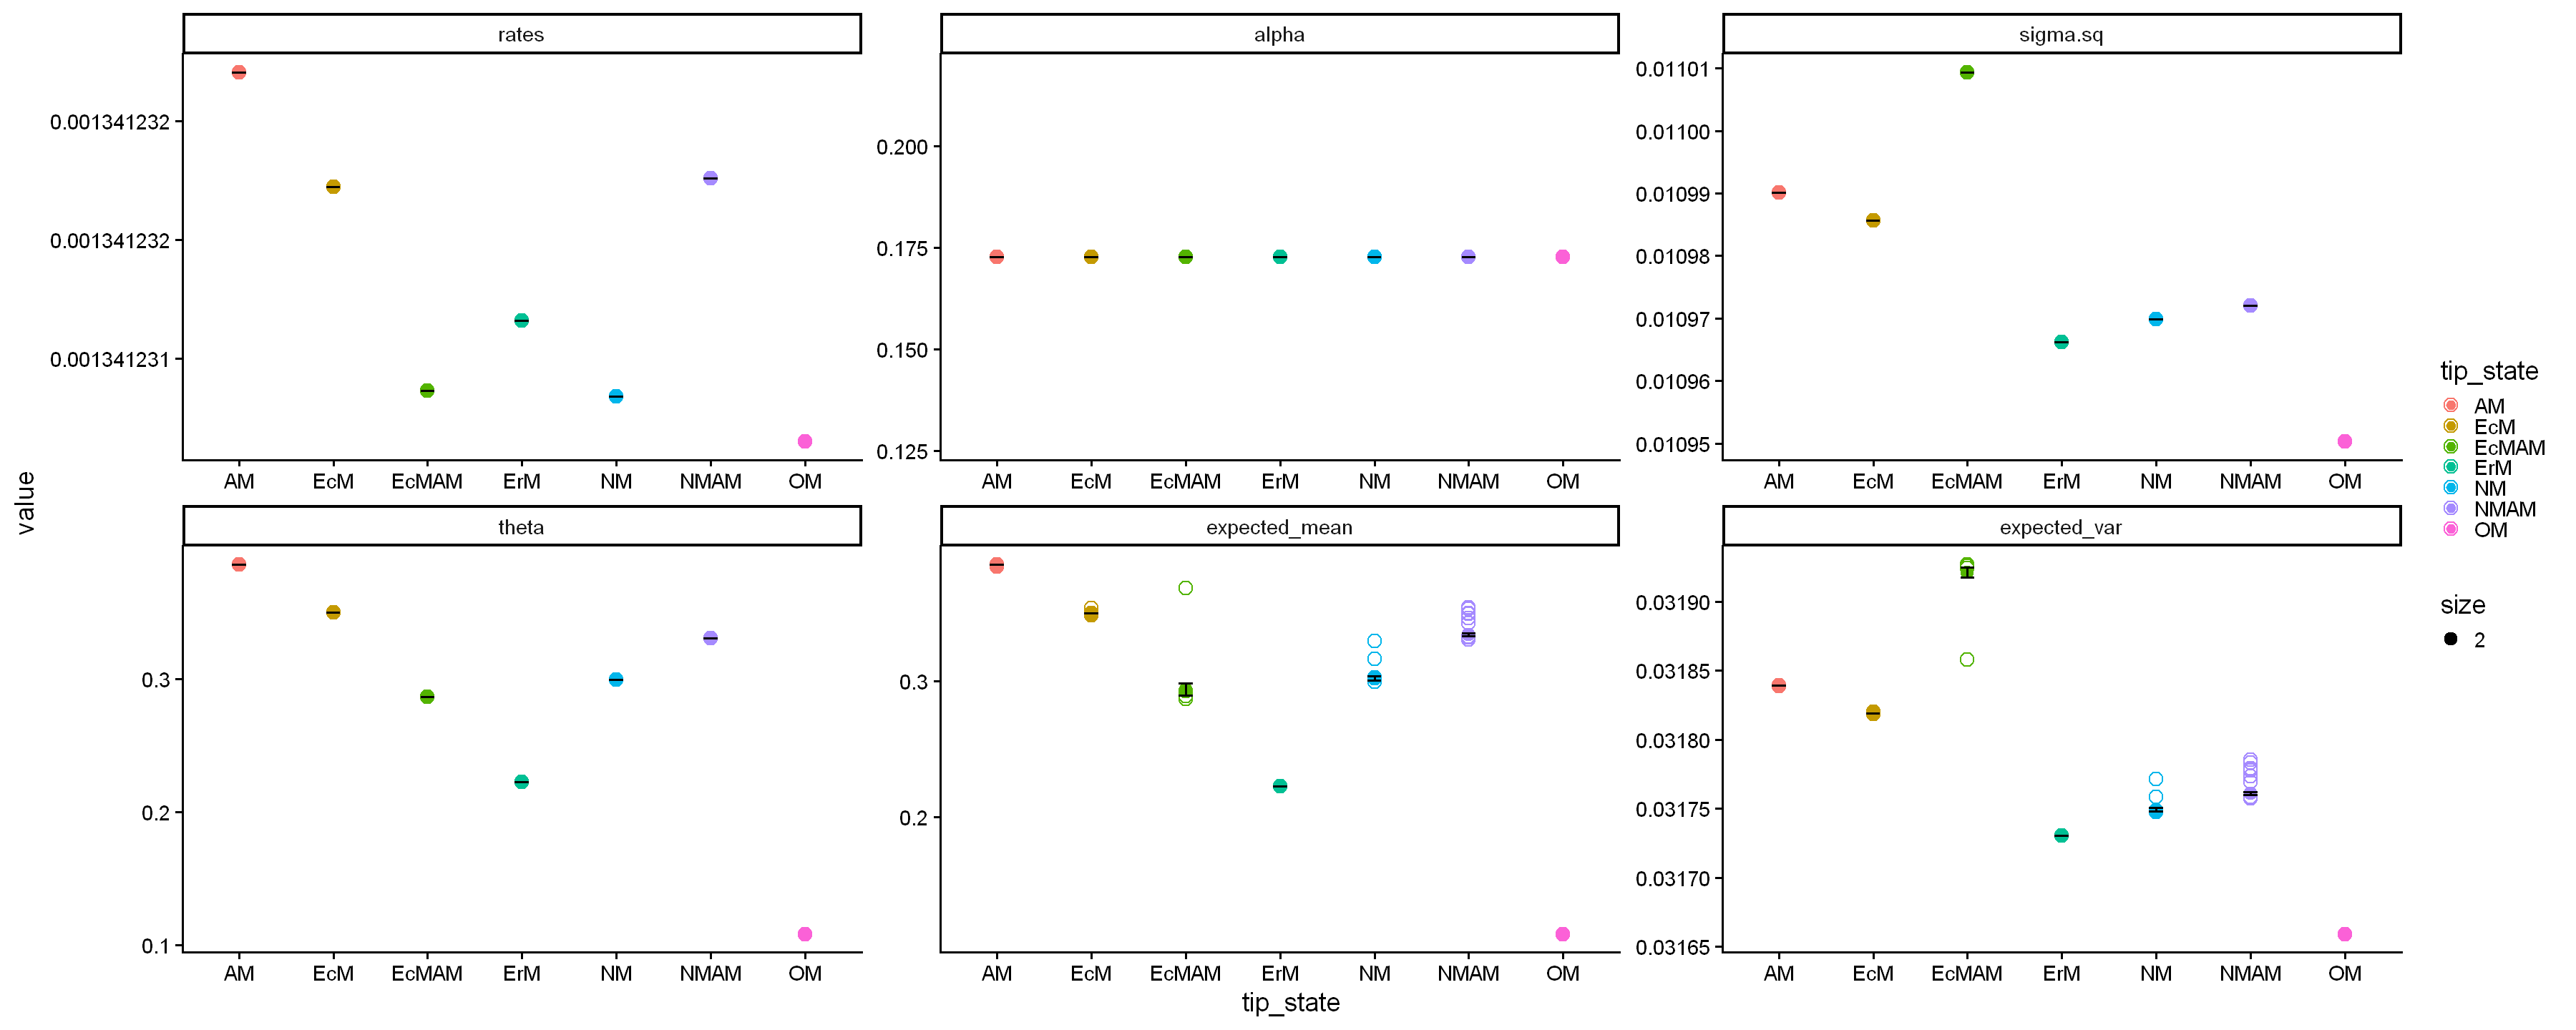

In [14]:
plot_df <- reshape2::melt(avg_models_CD_RD_1005sp)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")
# ggplot2::ggsave(plot = plot, filename = "../plots/hOUwie_RD_CD_1005sp.png", device = "png", width = 22, height = 12, units = "in", dpi = 750)
plot(plt)

Using tip_state as id variables



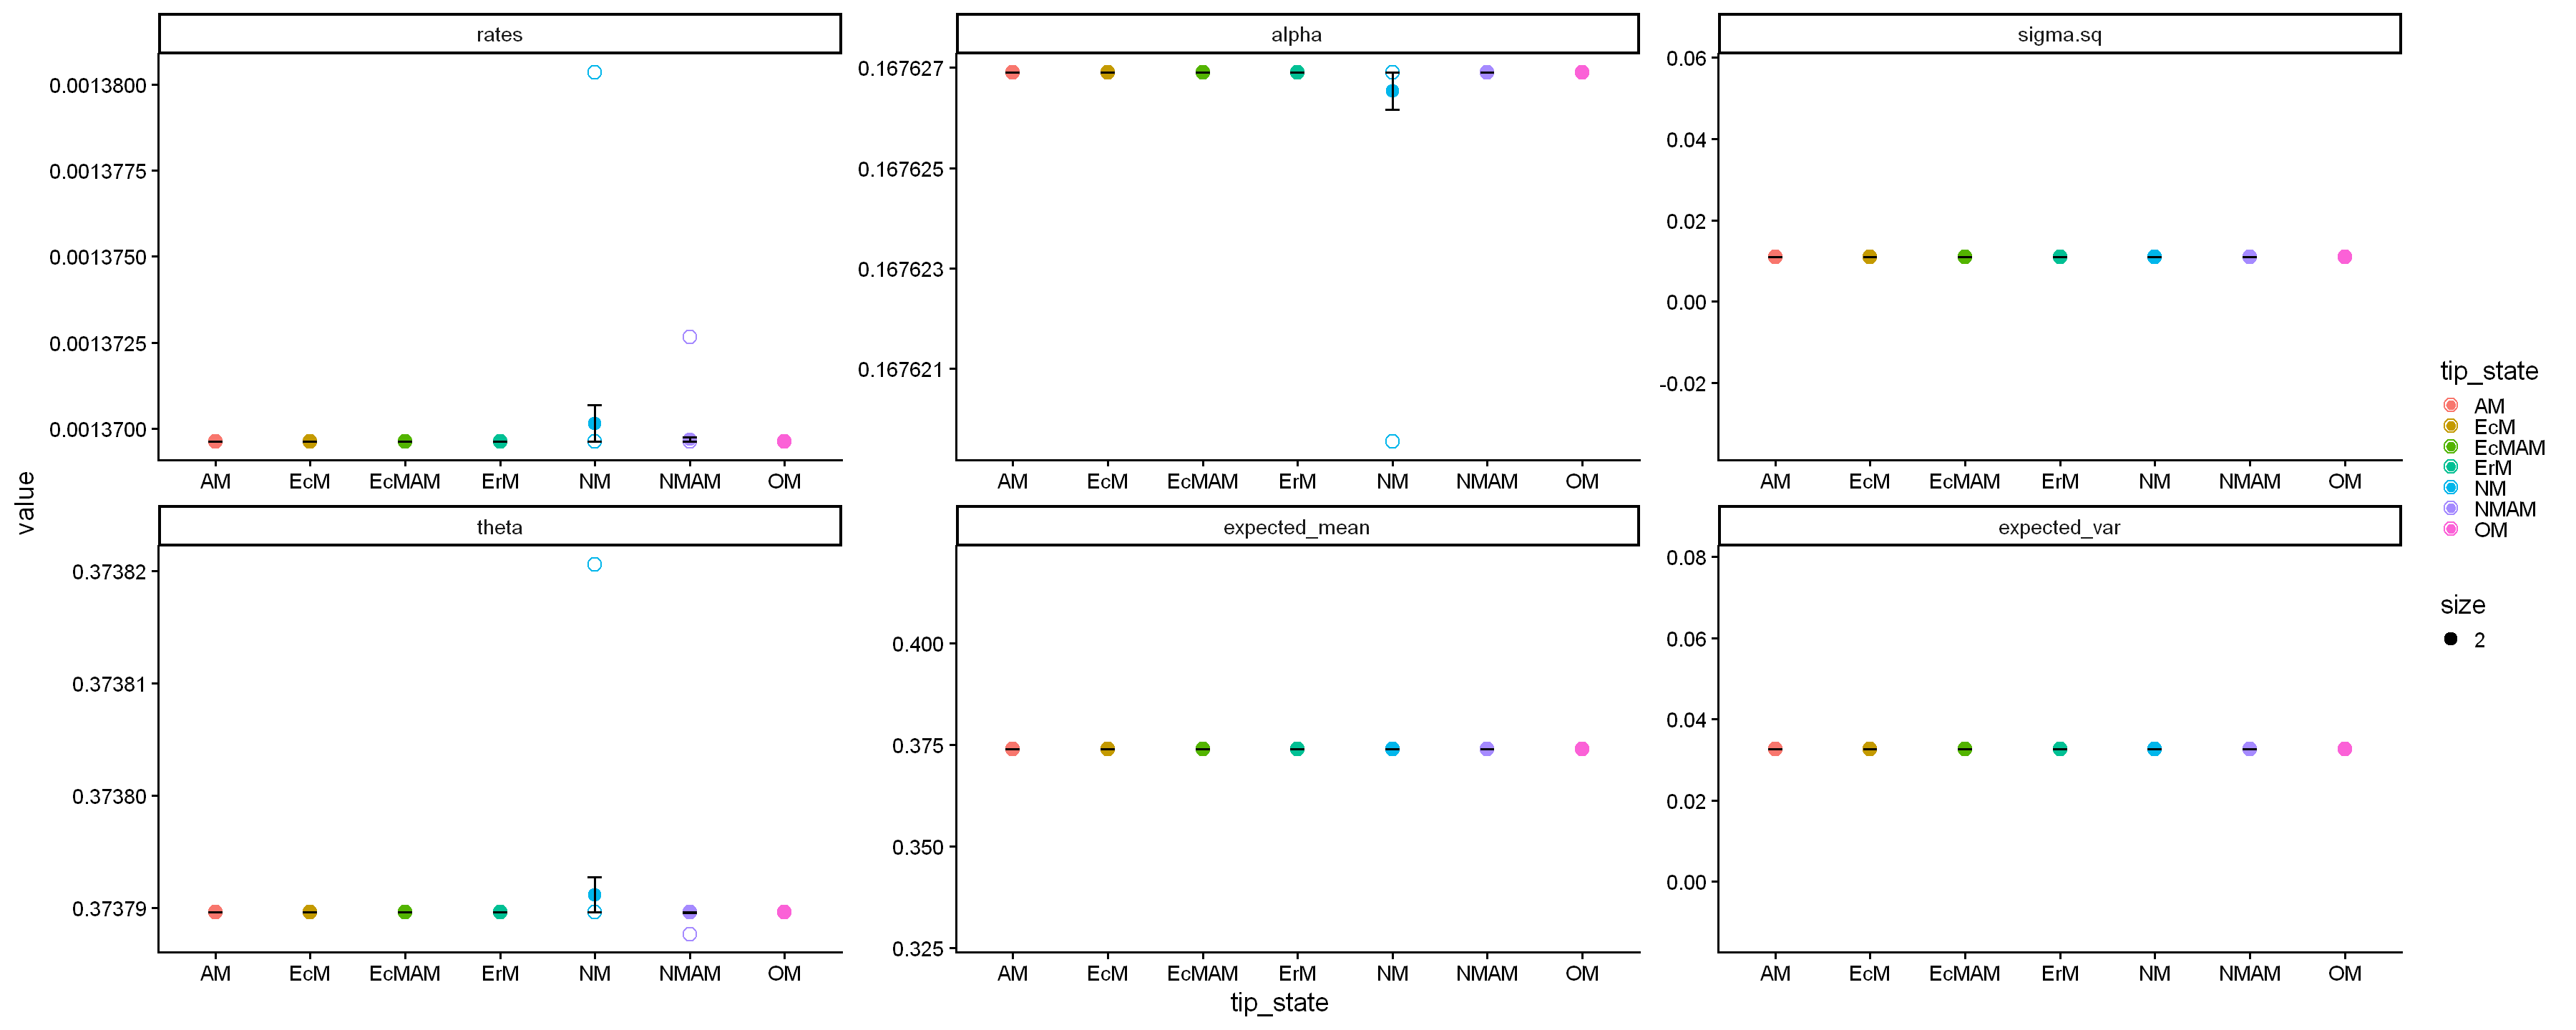

In [15]:
plot_df <- reshape2::melt(avg_models_CID_RD_1005sp)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")
# ggplot2::ggsave(plot = plot, filename = "../plots/hOUwie_RD_CID_1005sp.png", device = "png", width = 22, height = 12, units = "in", dpi = 750)
plot(plt)

In [21]:
#------------------------------------------------------------------------------------------------------------------------------------
# ROOT DIAMETER (RD <= 1.000 mm and root order == NA) or (RD <= 1.000 mm and root order == 1) subset (LOG TRANSFORMED)
#------------------------------------------------------------------------------------------------------------------------------------

# looks like the best model out of all these are
logged_RD_state_fits <- list.files("../rdata/parallel/LOG_RD_1005SP/")
logged_RD_state_fits_names <- logged_RD_state_fits |> gsub(pattern = "_1005SP.Rds", replacement = '') |> gsub(pattern = "_MYCO", replacement = '')
models_log_RD_1005sp <- lapply(FUN = readRDS, paste0("../rdata/parallel/LOG_RD_1005SP/", logged_RD_state_fits))
models_CD_log_RD_1005sp <- read_rds(dirpath = "../rdata/parallel/LOG_RD_1005SP/", cd = TRUE, regstrip = "_RD_MYCO_C[I]*D_1005SP.Rds")
models_CID_log_RD_1005sp <- read_rds(dirpath = "../rdata/parallel/LOG_RD_1005SP/", cd = FALSE, regstrip = "_RD_MYCO_C[I]*D_1005SP.Rds")

capture.output(avg_models_CD_logRD_1005sp <- OUwie::getModelAvgParams(models_CD_log_RD_1005sp, type = "AICc", force = FALSE), file = nullfile())
capture.output(avg_models_CID_logRD_1005sp <- OUwie::getModelAvgParams(models_CID_log_RD_1005sp, type = "AICc", force = FALSE), file = nullfile())

OUwie::getModelTable(models_CD_log_RD_1005sp, type = "AICc")
OUwie::getModelTable(models_CID_log_RD_1005sp, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARD_OUM_RD_CD,51,-891.9506,-263.0658,-626.0009,1891.467,1.286943,3.444622e-01
ARD_OUMA_RD_CD,57,-1261.3591,-254.5180,-1002.0219,2643.700,753.520418,1.554956e-164
ARD_OUMV_RD_CD,57,-1015.2664,-253.9821,-757.8765,2151.515,261.335047,1.170613e-57
ARD_OUMVA_RD_CD,63,-1261.2951,-262.3275,-997.1680,2657.160,766.979890,1.857936e-167
ER_OUM_RD_CD,10,-1345.1618,-262.3762,-1078.4157,2710.545,820.365049,4.748876e-179
ER_OUMA_RD_CD,16,-1298.6951,-262.3421,-1033.0176,2629.941,739.761013,1.511941e-161
ER_OUMV_RD_CD,16,-928.8146,-262.3076,-663.0691,1890.180,0.000000,6.555378e-01
ER_OUMVA_RD_CD,22,-1261.0066,-262.3808,-997.5747,2567.044,676.863858,6.878259e-148
SYM_OUM_RD_CD,30,-1322.6131,-240.4094,-1078.0701,2707.136,816.956012,2.611283e-178


,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARD_OUM_RD_CID,90,-1.106001e+03,-291.0183,-820.5732,2.409923e+03,293601091,0
ARD_OUMA_RD_CID,91,-1.358243e+03,-274.2612,-1088.9385,2.916826e+03,293601598,0
ARD_OUMV_RD_CID,91,-9.695400e+02,-298.6706,-695.0465,2.139420e+03,293600821,0
ARD_OUMVA_RD_CID,92,-1.340364e+03,-296.2951,-1051.9327,2.883491e+03,293601565,0
ER_OUM_RD_CID,8,-9.040159e+02,-262.3745,-638.3976,1.824176e+03,293600505,0
ER_OUMA_RD_CID,9,1.467993e+08,-262.9196,-973.3014,-2.935987e+08,0,1
ER_OUMV_RD_CID,9,-9.040199e+02,-262.3060,-638.3414,1.826221e+03,293600507,0
ER_OUMVA_RD_CID,10,-1.342213e+03,-262.2978,-1076.5537,2.704647e+03,293601386,0
SYM_OUM_RD_CID,48,-9.361223e+02,-293.8078,-1384.6181,1.973165e+03,293600654,0


Using tip_state as id variables



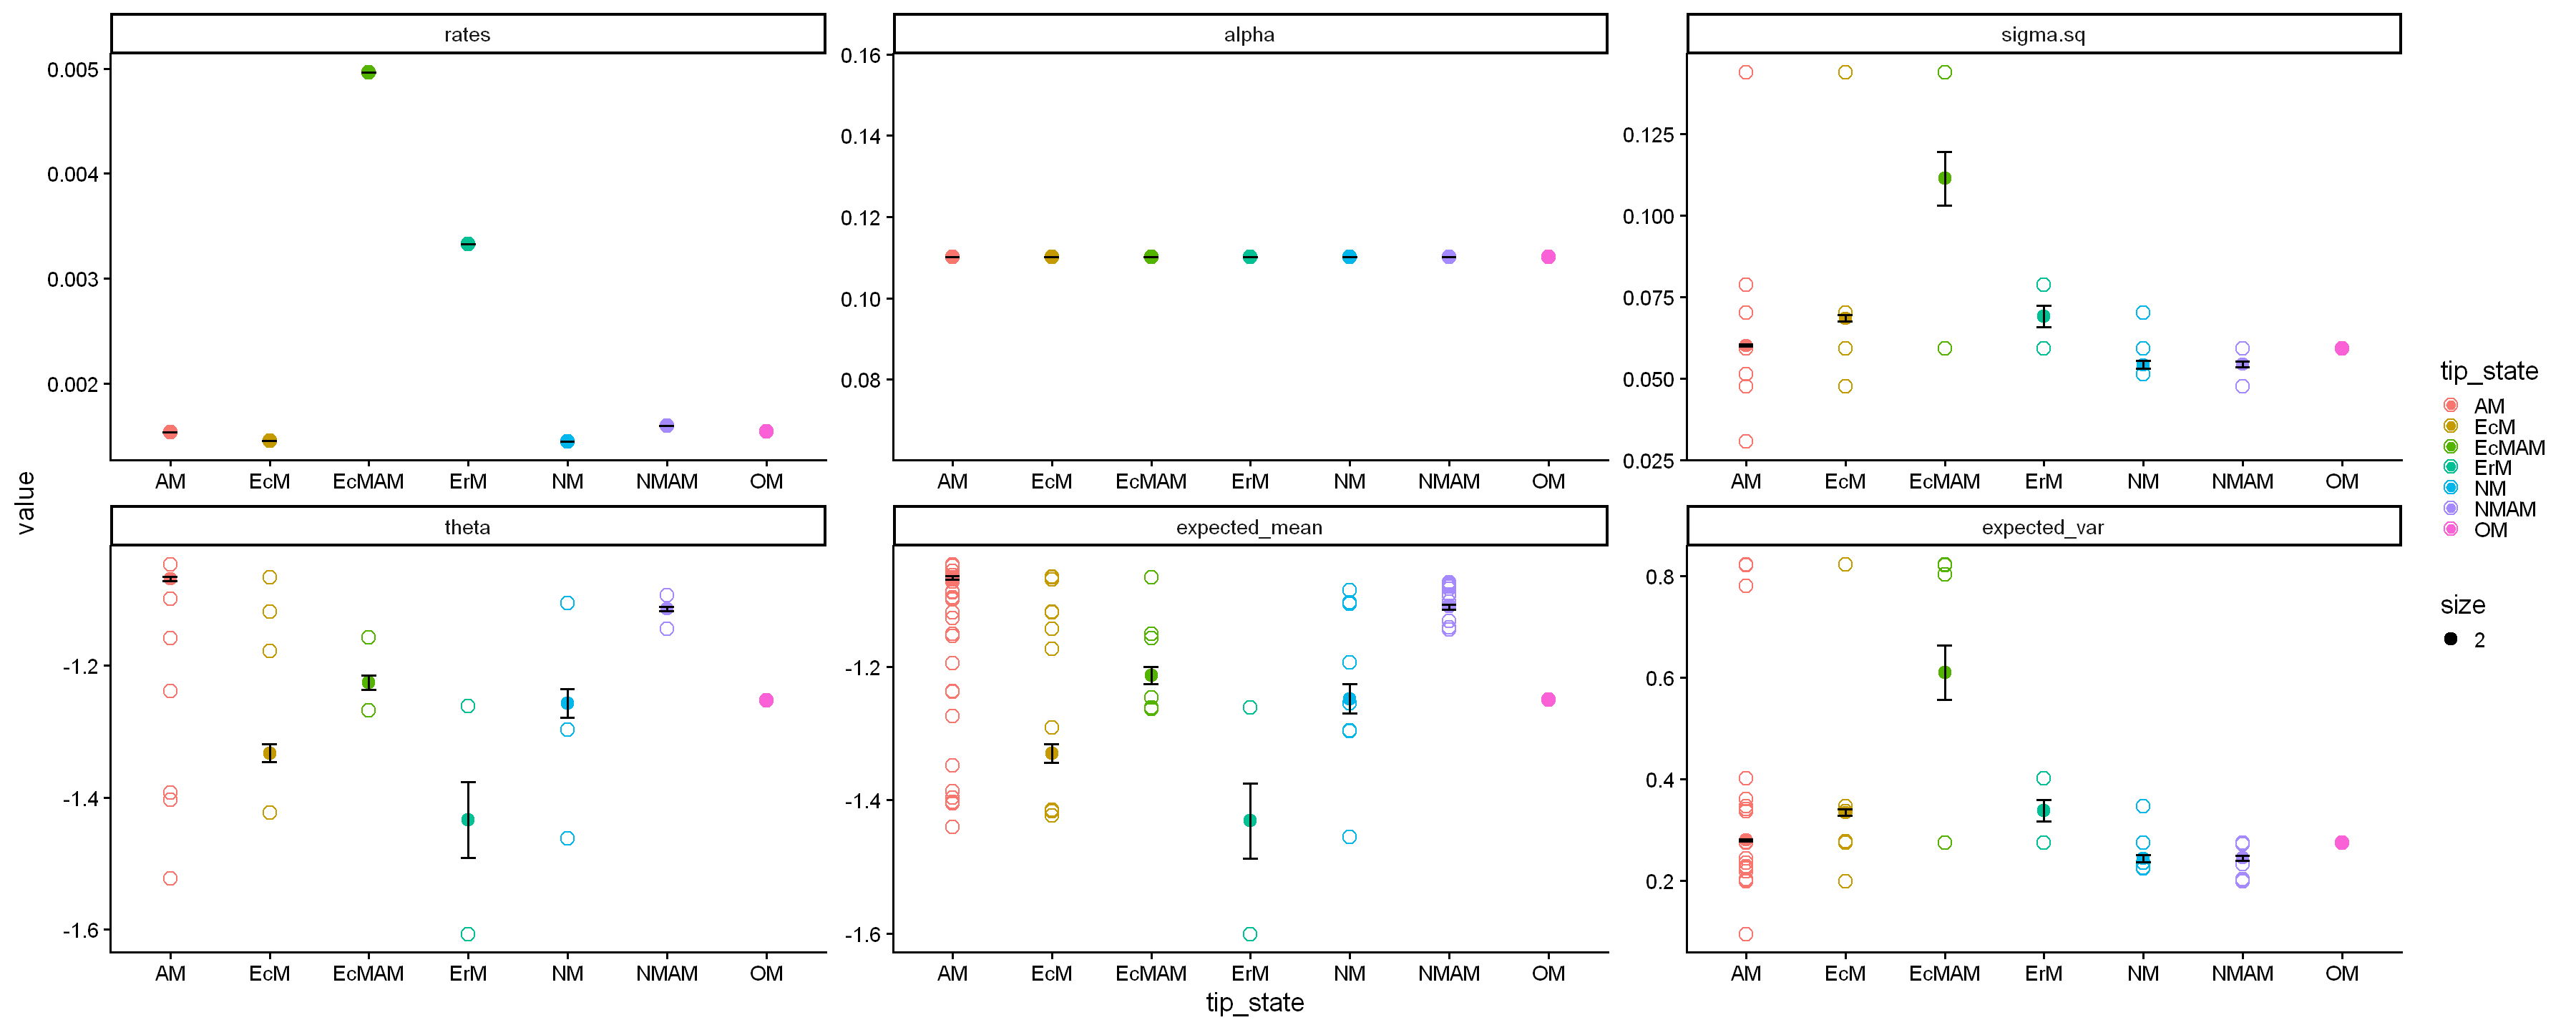

In [22]:
plot_df <- reshape2::melt(avg_models_CD_logRD_1005sp)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")
# ggplot2::ggsave(plot = plot, filename = "../plots/hOUwie_logRD_CD_1005sp.png", device = "png", width = 22, height = 12, units = "in", dpi = 750)
plot(plt)

Using tip_state as id variables



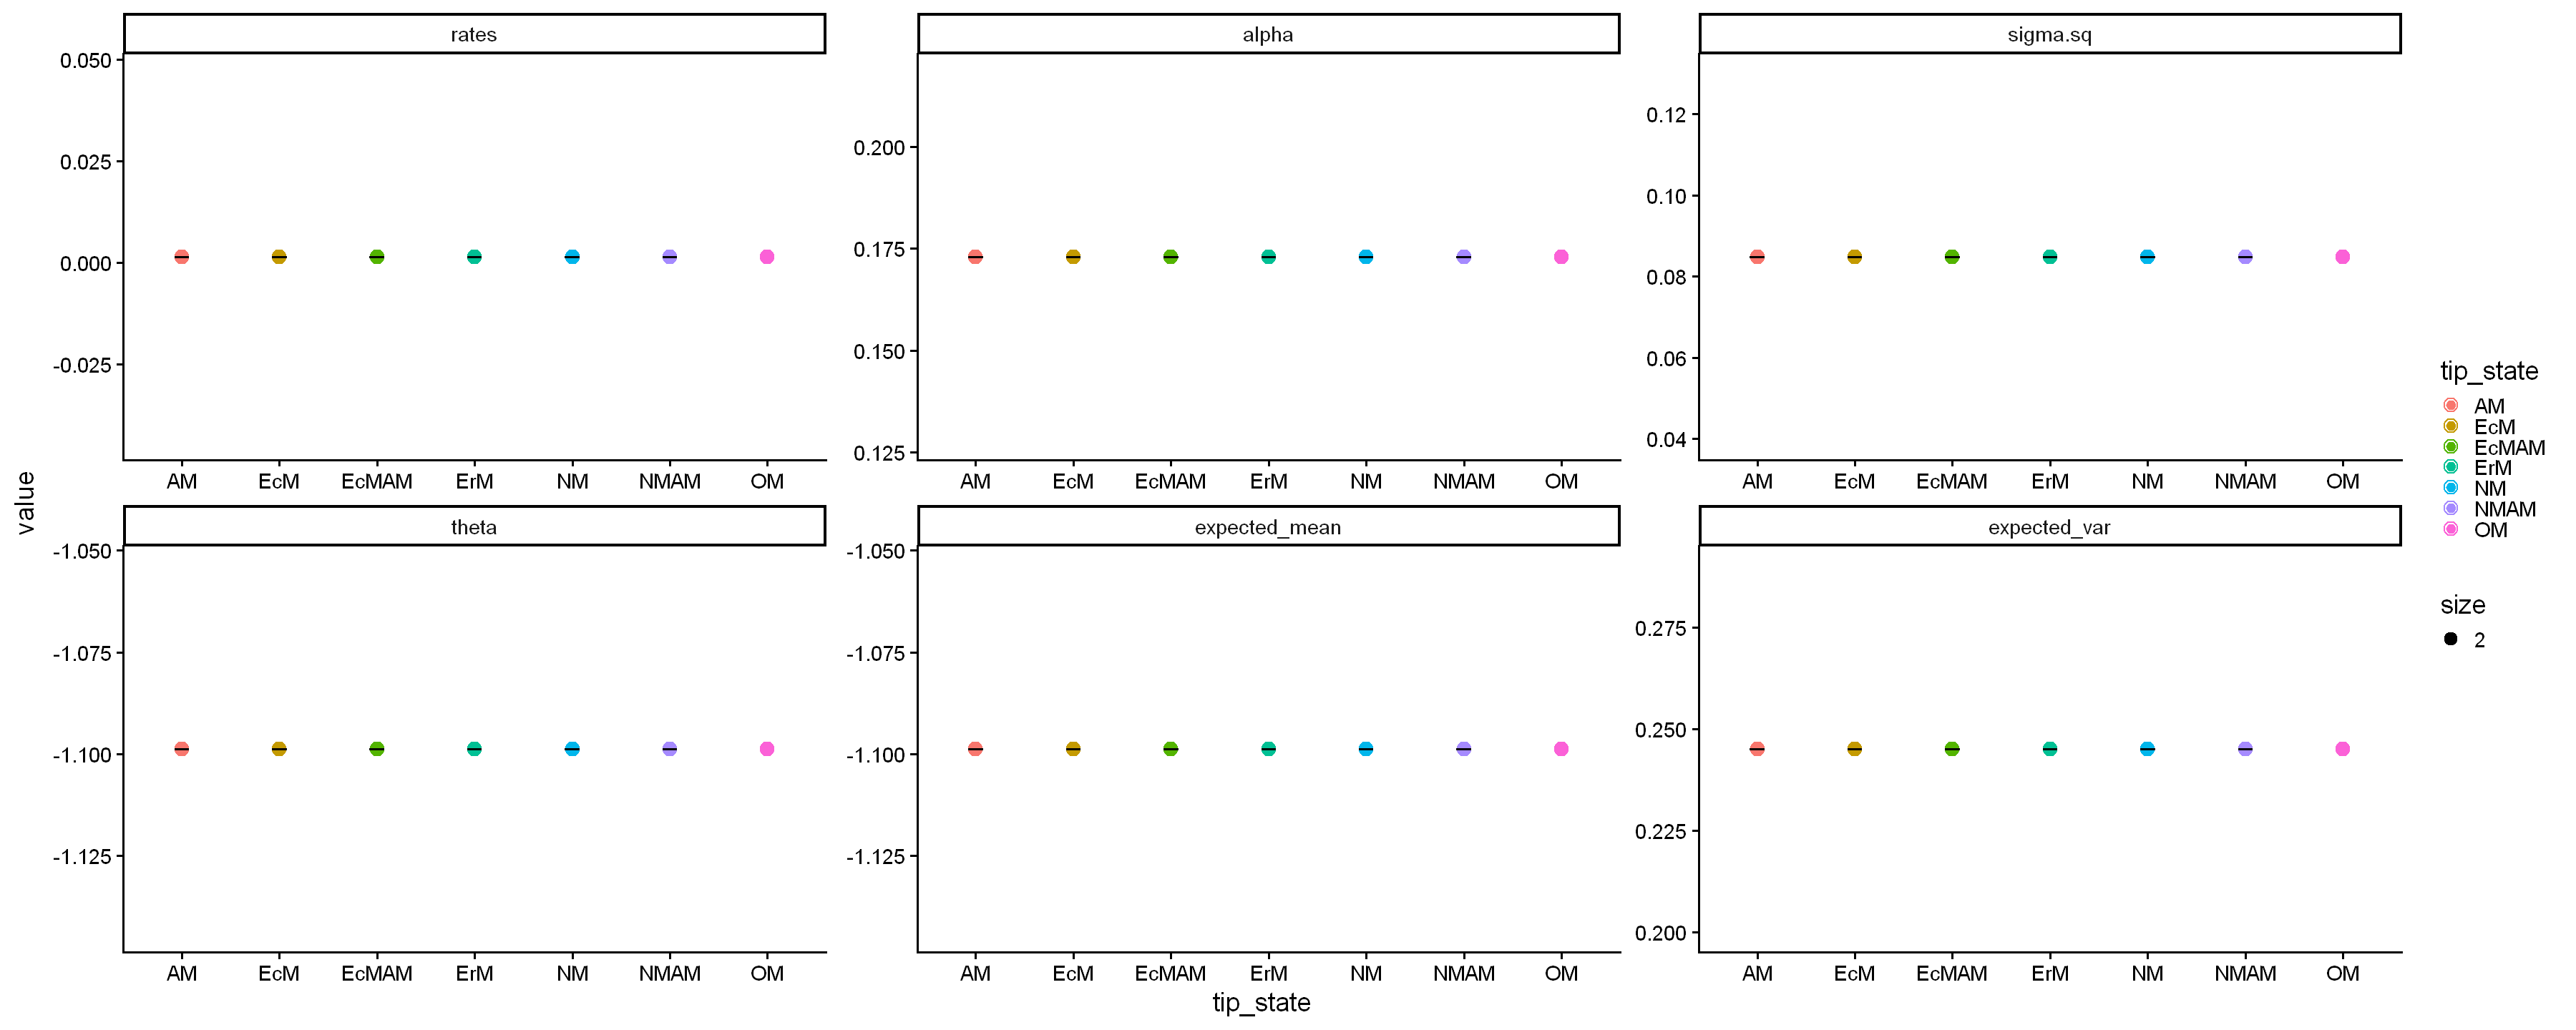

In [23]:
plot_df <- reshape2::melt(avg_models_CID_logRD_1005sp)
plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")
# ggplot2::ggsave(plot = plot, filename = "../plots/hOUwie_logRD_CID_1005sp.png", device = "png", width = 22, height = 12, units = "in", dpi = 750)
plot(plt)

## ___Specific root length (SRL)___
------------------

In [ ]:
load("./rdata/OU_SRL_CD.RData")
load("./rdata/OU_SRL_CID.RData")

models_CD_SRL <- list(EROUM=ER_OUM_SRL_CD, EROUMA=ER_OUMA_SRL_CD, EROUMV=ER_OUMV_SRL_CD, EROUMVA=ER_OUMVA_SRL_CD, ARDOUM=ARD_OUM_SRL_CD,
                     ARDOUMA=ARD_OUMA_SRL_CD, ARDOUMV=ARD_OUMV_SRL_CD, ARDOUMVA=ARD_OUMVA_SRL_CD, SYMOUM=SYM_OUM_SRL_CD, SYMOUMA=SYM_OUMA_SRL_CD,
                     SYMOUMV=SYM_OUMV_SRL_CD, SYMOUMVA=SYM_OUMVA_SRL_CD)

models_CID_SRL <- list(EROUM=ER_OUM_SRL_CID, EROUMA=ER_OUMA_SRL_CID, EROUMV=ER_OUMV_SRL_CID, EROUMVA=ER_OUMVA_SRL_CID, ARDOUM=ARD_OUM_SRL_CID,
                        ARDOUMA=ARD_OUMA_SRL_CID, ARDOUMV=ARD_OUMV_SRL_CID, ARDOUMVA=ARD_OUMVA_SRL_CID, SYMOUM=SYM_OUM_SRL_CID, SYMOUMA=SYM_OUMA_SRL_CID,
                        SYM_OUMV=SYM_OUMV_SRL_CID, SYMOUMVA=SYM_OUMVA_SRL_CID)

lapply(models_CID_SRL, function(mod){c(mod$loglik, mod$AIC, mod$AICc)}) |> as.data.frame(row.names = c("lnLik", "AIC", "AICc"))
lapply(models_CD_SRL, function(mod){c(mod$loglik, mod$AIC, mod$AICc)}) |> as.data.frame(row.names = c("lnLik", "AIC", "AICc"))

avg_models_CID_SRL <- OUwie::getModelAvgParams(models_CID_SRL, type = "AICc", force = FALSE)
avg_models_CD_SRL <- OUwie::getModelAvgParams(models_CD_SRL, type = "AICc", force = FALSE)

plot_df <- reshape2::melt(avg_models_CD_SRL)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")
ggplot2::ggsave(plot = plot, filename = "../plots/hOUwie_SRL_CD.png", device = "png", width = 22, height = 12, units = "in", dpi = 750)

plot_df <- reshape2::melt(avg_models_CID_SRL)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")
ggplot2::ggsave(plot = plot, filename = "../plots/hOUwie_SRL_CID.png", device = "png", width = 22, height = 12, units = "in", dpi = 750)

In [ ]:
load("./rdata/OU_SRL_CID_4states.RData")
load("./rdata/OU_SRL_CD_4states.RData")


models_CD_SRL_4states <- list(EROUM=ER_OUM_SRL_CD, EROUMA=ER_OUMA_SRL_CD, EROUMV=ER_OUMV_SRL_CD, EROUMVA=ER_OUMVA_SRL_CD, ARDOUM=ARD_OUM_SRL_CD,
                              ARDOUMA=ARD_OUMA_SRL_CD, ARDOUMV=ARD_OUMV_SRL_CD, ARDOUMVA=ARD_OUMVA_SRL_CD, SYMOUM=SYM_OUM_SRL_CD, SYMOUMA=SYM_OUMA_SRL_CD,
                              SYMOUMV=SYM_OUMV_SRL_CD, SYMOUMVA=SYM_OUMVA_SRL_CD)

models_CID_SRL_4states <- list(EROUM=ER_OUM_SRL_CID, EROUMA=ER_OUMA_SRL_CID, EROUMV=ER_OUMV_SRL_CID, EROUMVA=ER_OUMVA_SRL_CID, ARDOUM=ARD_OUM_SRL_CID,
                               ARDOUMA=ARD_OUMA_SRL_CID, ARDOUMV=ARD_OUMV_SRL_CID, ARDOUMVA=ARD_OUMVA_SRL_CID, SYMOUM=SYM_OUM_SRL_CID, SYMOUMA=SYM_OUMA_SRL_CID,
                               SYM_OUMV=SYM_OUMV_SRL_CID, SYMOUMVA=SYM_OUMVA_SRL_CID)

lapply(models_CID_SRL_4states, function(mod){c(mod$loglik, mod$AIC, mod$AICc)}) |> as.data.frame(row.names = c("lnLik", "AIC", "AICc"))
lapply(models_CD_SRL_4states, function(mod){c(mod$loglik, mod$AIC, mod$AICc)}) |> as.data.frame(row.names = c("lnLik", "AIC", "AICc"))

avg_models_CD_SRL_4states <- OUwie::getModelAvgParams(models_CD_SRL_4states, type = "AICc", force = FALSE)
avg_models_CID_SRL_4states <- OUwie::getModelAvgParams(models_CID_SRL_4states, type = "AICc", force = FALSE)

plot_df <- reshape2::melt(avg_models_CID_SRL_4states)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")
ggplot2::ggsave(plot = plot, filename = "../plots/hOUwie_SRL_CID_4states.png", device = "png", width = 22, height = 12, units = "in", dpi = 750)


plot_df <- reshape2::melt(avg_models_CD_SRL_4states)
plot <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) + facet_wrap(~variable, scales = "free")
ggplot2::ggsave(plot = plot, filename = "../plots/hOUwie_SRL_CD_4states.png", device = "png", width = 22, height = 12, units = "in", dpi = 750)


stderr_ <- function(df) { lapply(X=df, FUN=function(column) {sd(column) / sqrt(length(column))}) |> unlist() }

avg_models_CD_SRL_4states |> split(~tip_state) |> lapply(function(df) { colMeans(df[, c("rates", "alpha", "sigma.sq", "theta")]) }) |> as.data.frame()
avg_models_CID_SRL_4states |> split(~tip_state) |> lapply(function(df) { colMeans(df[, c("rates", "alpha", "sigma.sq", "theta")]) }) |> as.data.frame()


avg_models_CD_SRL_4states |> split(~tip_state) |> lapply(function(df) { stderr_(df[, c("rates", "alpha", "sigma.sq", "theta")]) })
avg_models_CID_SRL_4states |> split(~tip_state) |> lapply(function(df) { stderr_(df[, c("rates", "alpha", "sigma.sq", "theta")]) })
